In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [31]:
df = pd.read_csv(r"C:\projects\titanic\train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [32]:
dup = df[df.duplicated('Ticket', keep=False)].sort_values('Ticket')
dup

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
257,258,1,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.500,B77,S
504,505,1,1,"Maioni, Miss. Roberta",female,16.0,0,0,110152,86.500,B79,S
759,760,1,1,"Rothes, the Countess. of (Lucy Noel Martha Dye...",female,33.0,0,0,110152,86.500,B77,S
262,263,0,1,"Taussig, Mr. Emil",male,52.0,1,1,110413,79.650,E67,S
558,559,1,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.650,E67,S
...,...,...,...,...,...,...,...,...,...,...,...,...
147,148,0,3,"Ford, Miss. Robina Maggie ""Ruby""",female,9.0,2,2,W./C. 6608,34.375,NaN,S
436,437,0,3,"Ford, Miss. Doolina Margaret ""Daisy""",female,21.0,2,2,W./C. 6608,34.375,NaN,S
736,737,0,3,"Ford, Mrs. Edward (Margaret Ann Watson)",female,48.0,1,3,W./C. 6608,34.375,NaN,S
540,541,1,1,"Crosby, Miss. Harriet R",female,36.0,0,2,WE/P 5735,71.000,B22,S


In [33]:
# Title
df["Title"] = df["Name"].str.extract(r' ([A-Za-z]+)\.')
counts = df["Title"].value_counts()
rare_counts = counts[counts<3].index
df["Title"] = df["Title"].replace(rare_counts, "Rare")

# FamilySize
df["FamilySize"] = df["SibSp"]+ df["Parch"]+1
# IsAlone
df["IsAlone"] = (df["FamilySize"]==1).astype(int)

# TicketFreq
df["TicketFreq"] = df.groupby("Ticket")["PassengerId"].transform("count")

# HasCabin
df["HasCabin"] = df["Cabin"].notna().astype(int)

# FarePerPerson
df["FarePerPerson"] = df["Fare"]/df["TicketFreq"]

# IsChild
df["IsChild"] = (df["Age"]<12).astype(int)

# GroupSurvival
g = df.groupby("Ticket")["Survived"]
# всего выжило в группе билета
total = g.transform("sum")
# исход скольких людей известен
known = g.transform("count")
# вижил ли сам человек
own = df['Survived'].fillna(0)
# известенно вижыл он или нет
own_known = df['Survived'].notna().astype(int)

df['GroupSurvival'] = (total - own) / (known - own_known)
df['GroupSurvival'] = df['GroupSurvival'].fillna(0.5)


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    891 non-null    int64  
 1   Survived       891 non-null    int64  
 2   Pclass         891 non-null    int64  
 3   Name           891 non-null    str    
 4   Sex            891 non-null    str    
 5   Age            714 non-null    float64
 6   SibSp          891 non-null    int64  
 7   Parch          891 non-null    int64  
 8   Ticket         891 non-null    str    
 9   Fare           891 non-null    float64
 10  Cabin          204 non-null    str    
 11  Embarked       889 non-null    str    
 12  Title          891 non-null    str    
 13  FamilySize     891 non-null    int64  
 14  IsAlone        891 non-null    int64  
 15  TicketFreq     891 non-null    int64  
 16  HasCabin       891 non-null    int64  
 17  FarePerPerson  891 non-null    float64
 18  IsChild        891 no

Визуальный анализ данных

<Axes: xlabel='Survived', ylabel='count'>

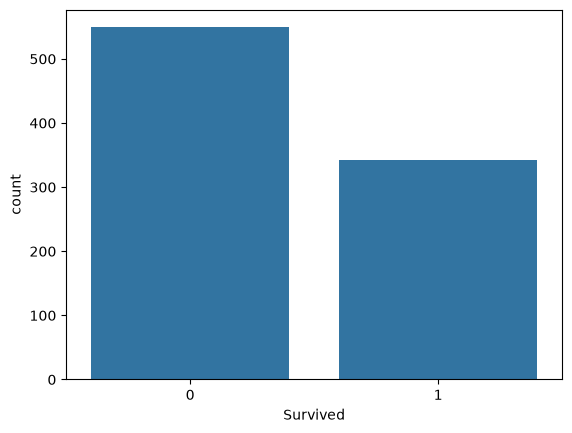

In [35]:
# распределение классов
sns.countplot(df, x = "Survived")

Вывод: дисбаланс у классов умеренный

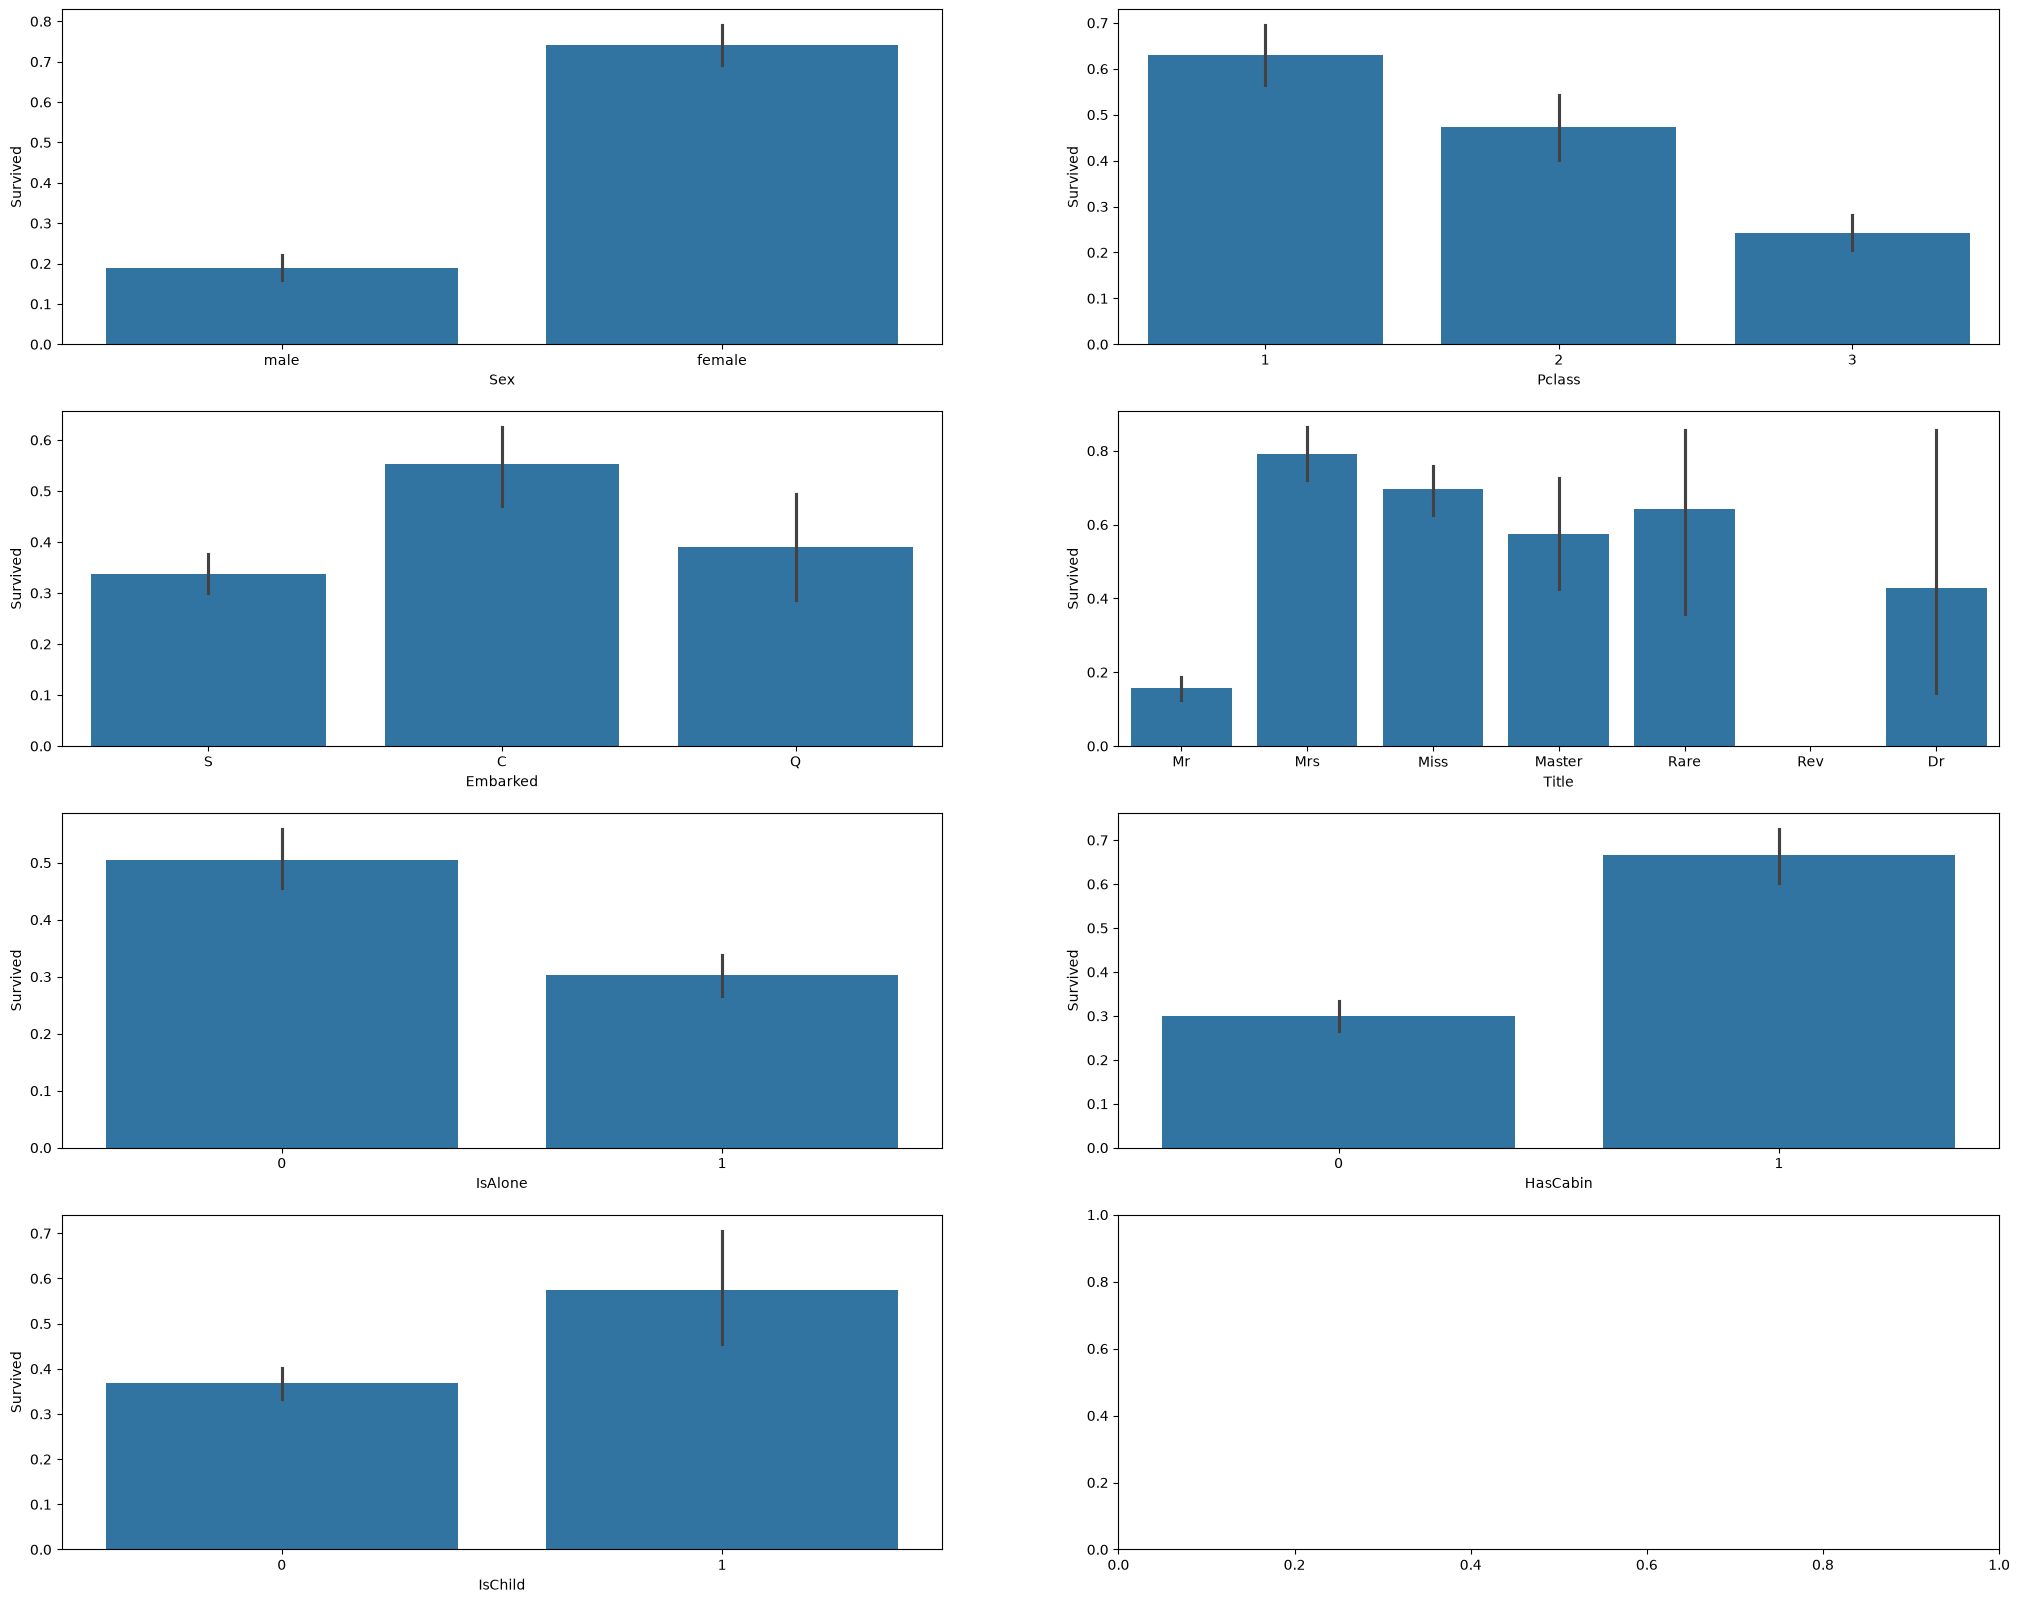

In [36]:
# выживаемость по категориальным фичам
cols = ['Sex', 'Pclass', 'Embarked', 'Title', 'IsAlone', 'HasCabin', 'IsChild']

fig, axes = plt.subplots(4,2,figsize = (25,20))
axes = axes.flatten()
for col, ax in zip(cols, axes):
    sns.barplot(data = df, x = col, y = "Survived", ax = ax)


In [37]:
Вывод: Sex, Pclass, HasCabin, IsChild, Title (Mr) - хорошие признаки

SyntaxError: invalid syntax (2143260508.py, line 1)

Pclass         1         2         3
Sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447


<Axes: xlabel='Pclass', ylabel='Sex'>

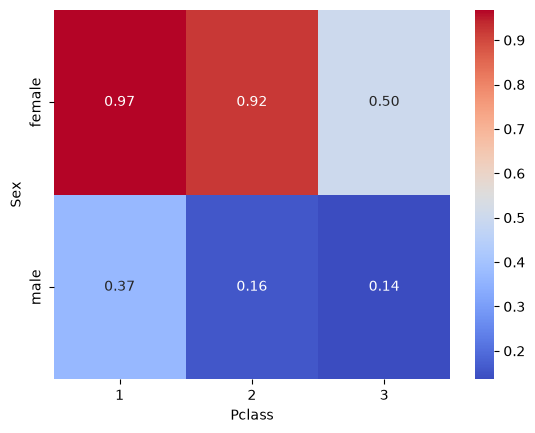

In [ ]:
pivot_data = df.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc="mean")
print(pivot_data)
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='coolwarm')

Вывод: женщины любых классов выживали чаще чем мужчины -> можно сделать фичу Sex_Pclass

<Axes: xlabel='TicketFreq', ylabel='Survived'>

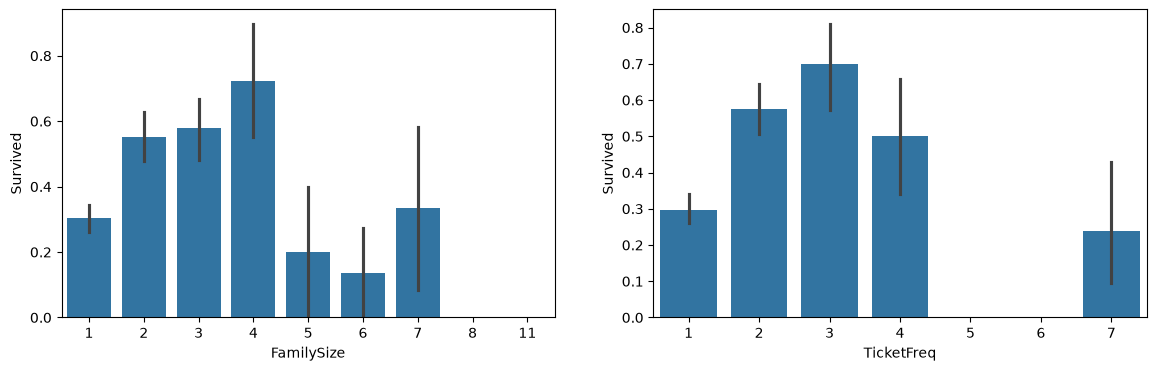

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=df, x='FamilySize', y='Survived', ax=axes[0])
sns.barplot(data=df, x='TicketFreq', y='Survived', ax=axes[1])

Вывод: графики похоже (возможно признаки сильно пересекаются по смылсу)

<Axes: xlabel='Title', ylabel='Age'>

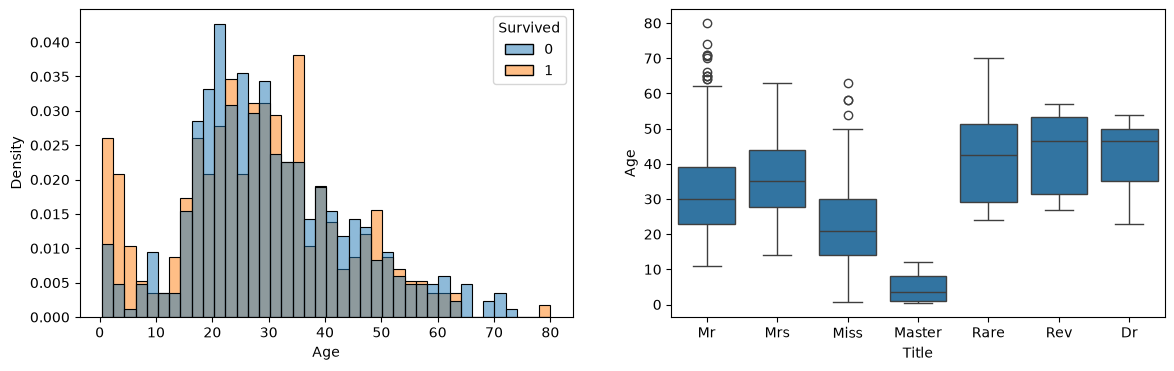

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=df, x='Age', hue='Survived', bins=40, stat='density', common_norm=False, ax=axes[0])
sns.boxplot(data=df, x='Title', y='Age', ax=axes[1])

<Axes: xlabel='Age', ylabel='Count'>

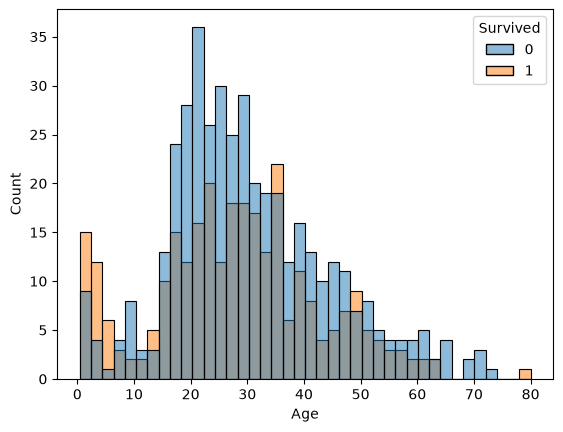

In [ ]:
sns.histplot(data=df, x='Age', hue='Survived', bins=40)

Вывод: 
дети выживают где-то до 8-12 лет
медианы возраста сильно отличаются от титула к титулу. Так что лучше заполнять пропуски в возрастах медианой по титулу


<Axes: xlabel='FarePerPerson', ylabel='Density'>

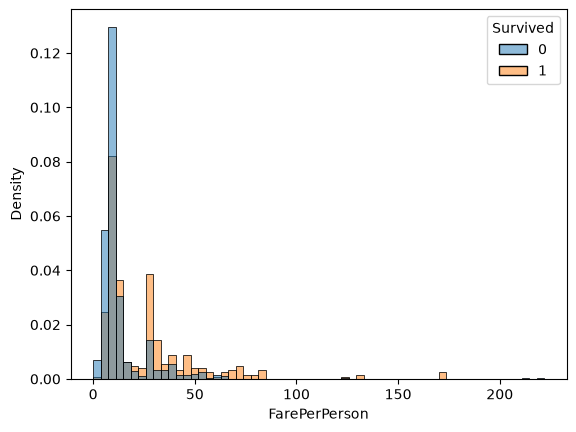

In [ ]:
sns.histplot(data=df, x='FarePerPerson', hue='Survived', log_scale=False, stat='density', common_norm=False)

Вывод:
Из экипажа почти все погибли: значит цена билета 0 может многое говорить при выживаемость

np.float64(0.6408529741863075)

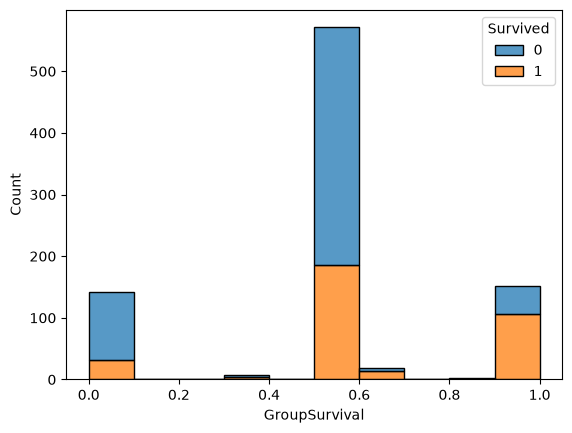

In [ ]:
sns.histplot(data=df, x='GroupSurvival', hue='Survived', multiple='stack', bins=10)
(df['GroupSurvival'] == 0.5).mean()

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,TicketFreq,HasCabin,FarePerPerson,IsChild,GroupSurvival
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0,1,0,7.2500,0,0.5
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0,1,1,71.2833,0,0.5
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1,1,0,7.9250,0,0.5
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0,2,1,26.5500,0,0.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1,1,0,8.0500,0,0.5


<Axes: >

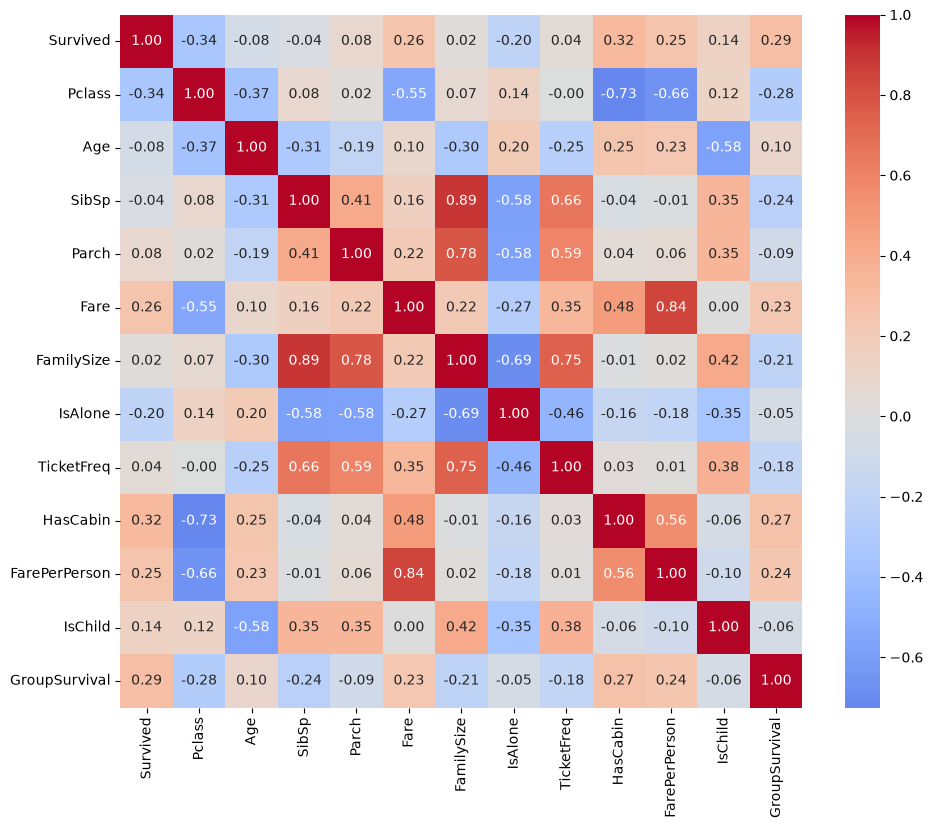

In [ ]:
num = df.select_dtypes('number').drop(columns='PassengerId')
plt.figure(figsize=(11, 9))
sns.heatmap(num.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)

In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    891 non-null    int64  
 1   Survived       891 non-null    int64  
 2   Pclass         891 non-null    int64  
 3   Name           891 non-null    str    
 4   Sex            891 non-null    str    
 5   Age            714 non-null    float64
 6   SibSp          891 non-null    int64  
 7   Parch          891 non-null    int64  
 8   Ticket         891 non-null    str    
 9   Fare           891 non-null    float64
 10  Cabin          204 non-null    str    
 11  Embarked       889 non-null    str    
 12  Title          891 non-null    str    
 13  FamilySize     891 non-null    int64  
 14  IsAlone        891 non-null    int64  
 15  TicketFreq     891 non-null    int64  
 16  HasCabin       891 non-null    int64  
 17  FarePerPerson  891 non-null    float64
 18  IsChild        891 no

In [38]:
# Заполняем пропуски медианой по титулу
df["Age"] = df.groupby("Title")["Age"].transform(lambda x: x.fillna(x.median()))

In [39]:
df["Embarked"]=df["Embarked"].fillna("S")

In [40]:
df["HasGroup "] = df["TicketFreq"]>1

In [41]:
df["Title"].value_counts()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       14
Dr          7
Rev         6
Name: count, dtype: int64

In [42]:
df["Title"] = df["Title"].replace({"Dr":"Rare","Rev":"Rare"})

In [43]:
df["Title"].value_counts()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

In [44]:
# После вставки пропусков в возрасте опять считаю IsChild
df["IsChild"] = (df["Age"]<12).astype(int)

In [45]:
df = df.drop(columns = ["Name", "Ticket", "Cabin", "PassengerId"])

In [46]:
df['Sex_Pclass'] = df['Sex'].astype(str) + '_' + df['Pclass'].astype(str)

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Survived       891 non-null    int64  
 1   Pclass         891 non-null    int64  
 2   Sex            891 non-null    str    
 3   Age            891 non-null    float64
 4   SibSp          891 non-null    int64  
 5   Parch          891 non-null    int64  
 6   Fare           891 non-null    float64
 7   Embarked       891 non-null    str    
 8   Title          891 non-null    str    
 9   FamilySize     891 non-null    int64  
 10  IsAlone        891 non-null    int64  
 11  TicketFreq     891 non-null    int64  
 12  HasCabin       891 non-null    int64  
 13  FarePerPerson  891 non-null    float64
 14  IsChild        891 non-null    int64  
 15  GroupSurvival  891 non-null    float64
 16  HasGroup       891 non-null    bool   
 17  Sex_Pclass     891 non-null    str    
dtypes: bool(1), float64(4

### Работа с категориальными фичами

In [48]:
df["Sex"] = df["Sex"].map({'male': 0, 'female': 1})


In [49]:
df = pd.get_dummies(df, columns=['Sex_Pclass', "Embarked", "Title"], dtype=int)

### Обучение моделей

In [50]:
# # касс для кроссвалидации с сохранением пропорции между классами и функция для прогона модели по всем фолдам
# from sklearn.model_selection import StratifiedKFold, cross_val_score
# # модели
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# # обертка для создания пайплайна
# from sklearn.pipeline import make_pipeline
# # делаем среднее 0, а std единицей (нужно для логистической регрессии)
# from sklearn.preprocessing import StandardScaler

# # разделяем датасет на фичи и целевую переменную
# X = df.drop(columns='Survived').astype(float)
# y = df['Survived']

# # настройка кроссвалидации, делим на 5 фолдов, перемешиваем перед разделением
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# models = {
#     'logreg': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
#     'rf': RandomForestClassifier(n_estimators=500, max_depth=6, random_state=42),
# }
# for name, m in models.items():
#     s = cross_val_score(m, X, y, cv=cv, scoring='accuracy')
#     print(name, s.mean().round(4), s.std().round(4))

In [51]:
%pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [52]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [53]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [54]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,TicketFreq,...,Sex_Pclass_male_2,Sex_Pclass_male_3,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,0,22.0,1,0,7.2500,2,0,1,...,0,1,0,0,1,0,0,1,0,0
1,1,1,1,38.0,1,0,71.2833,2,0,1,...,0,0,1,0,0,0,0,0,1,0
2,1,3,1,26.0,0,0,7.9250,1,1,1,...,0,0,0,0,1,0,1,0,0,0
3,1,1,1,35.0,1,0,53.1000,2,0,2,...,0,0,0,0,1,0,0,0,1,0
4,0,3,0,35.0,0,0,8.0500,1,1,1,...,0,1,0,0,1,0,0,1,0,0


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Survived             891 non-null    int64  
 1   Pclass               891 non-null    int64  
 2   Sex                  891 non-null    int64  
 3   Age                  891 non-null    float64
 4   SibSp                891 non-null    int64  
 5   Parch                891 non-null    int64  
 6   Fare                 891 non-null    float64
 7   FamilySize           891 non-null    int64  
 8   IsAlone              891 non-null    int64  
 9   TicketFreq           891 non-null    int64  
 10  HasCabin             891 non-null    int64  
 11  FarePerPerson        891 non-null    float64
 12  IsChild              891 non-null    int64  
 13  GroupSurvival        891 non-null    float64
 14  HasGroup             891 non-null    bool   
 15  Sex_Pclass_female_1  891 non-null    int64  
 16  S

In [ ]:
# ============ ИМПОРТЫ ============

# кросс-валидация
from sklearn.model_selection import StratifiedKFold, cross_validate

# модели
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

# бустинги
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# пайплайн и препроцессинг
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd


# ============ ДАННЫЕ ============

X = df.drop(columns='Survived').astype(float)
y = df['Survived']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# ============ МОДЕЛИ ============

models = {
    # --- бейзлайны ---
    'dummy': DummyClassifier(strategy='most_frequent'),

    # --- линейные ---
    'logreg': make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=42),
    ),

    # --- метрические ---
    'knn': make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=5, weights='distance'),
    ),
    'svc_rbf': make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42),
    ),

    # --- вероятностные ---
    'gnb': GaussianNB(),

    # --- деревья ---
    'tree': DecisionTreeClassifier(max_depth=6, random_state=42),

    # --- бэггинги ---
    'rf': RandomForestClassifier(
        n_estimators=500, max_depth=6, random_state=42, n_jobs=-1,
    ),
    'et': ExtraTreesClassifier(
        n_estimators=500, max_depth=6, random_state=42, n_jobs=-1,
    ),

    # --- бустинги ---
    'hgb': HistGradientBoostingClassifier(
        max_iter=500, learning_rate=0.05, max_depth=6, random_state=42,
    ),
    'gb': GradientBoostingClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=3, random_state=42,
    ),
    'xgb': XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, n_jobs=-1,
        tree_method='hist',
    ),
    'lgbm': LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1,
    ),
    'catboost': CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        random_state=42, verbose=0, allow_writing_files=False,
    ),
}


# ============ АНСАМБЛИ (добавим после прогона базовых) ============

# Простой soft-voting из 3-4 сильных моделей.
# Работает лучше, если базовые модели разнородны (деревья + линейная + SVC).
voting = VotingClassifier(
    estimators=[
        ('logreg', make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))),
        ('rf',     RandomForestClassifier(n_estimators=500, max_depth=6, random_state=42, n_jobs=-1)),
        ('lgbm',   LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1, verbose=-1)),
        ('svc',    make_pipeline(StandardScaler(),
                                 SVC(kernel='rbf', C=1.0, probability=True, random_state=42))),
    ],
    voting='soft',
    n_jobs=-1,
)
models['voting'] = voting

# Стекинг: базовые модели отдают out-of-fold предсказания мета-модели (логрег).
# На маленьких данных легко переобучается — обязательно сравнить с одиночными моделями.
stacking = StackingClassifier(
    estimators=[
        ('rf',   RandomForestClassifier(n_estimators=500, max_depth=6, random_state=42, n_jobs=-1)),
        ('lgbm', LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1, verbose=-1)),
        ('svc',  make_pipeline(StandardScaler(),
                               SVC(kernel='rbf', C=1.0, probability=True, random_state=42))),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1,
)
models['stacking'] = stacking


# ============ ПРОГОН ============

# несколько метрик сразу — accuracy на Titanic обманчива из-за дисбаланса классов (~62/38)
scoring = {
    'acc':      'accuracy',
    'auc':      'roc_auc',
    'f1':       'f1',
    'bal_acc':  'balanced_accuracy',
}

rows = []
for name, m in models.items():
    res = cross_validate(m, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    rows.append({
        'model':    name,
        'acc':      res['test_acc'].mean(),
        'acc_std':  res['test_acc'].std(),
        'auc':      res['test_auc'].mean(),
        'auc_std':  res['test_auc'].std(),
        'f1':       res['test_f1'].mean(),
        'bal_acc':  res['test_bal_acc'].mean(),
    })

results = (
    pd.DataFrame(rows)
      .sort_values('auc', ascending=False)
      .round(4)
      .reset_index(drop=True)
)

print(results.to_string(index=False))

   model    acc  acc_std    auc  auc_std     f1  bal_acc
     xgb 0.8496   0.0110 0.8992   0.0232 0.7945   0.8322
      gb 0.8552   0.0145 0.8987   0.0258 0.8026   0.8389
catboost 0.8519   0.0121 0.8974   0.0183 0.8000   0.8368
  voting 0.8440   0.0105 0.8972   0.0182 0.7759   0.8178
stacking 0.8496   0.0099 0.8959   0.0224 0.7865   0.8256
  logreg 0.8406   0.0155 0.8903   0.0082 0.7773   0.8188
      rf 0.8440   0.0150 0.8900   0.0196 0.7789   0.8199
     hgb 0.8395   0.0158 0.8890   0.0266 0.7822   0.8229
    lgbm 0.8260   0.0230 0.8866   0.0244 0.7693   0.8125
      et 0.8406   0.0118 0.8827   0.0194 0.7711   0.8145
 svc_rbf 0.8406   0.0185 0.8774   0.0204 0.7678   0.8117
     knn 0.8227   0.0104 0.8653   0.0191 0.7629   0.8076
     gnb 0.8227   0.0060 0.8641   0.0188 0.7718   0.8152
    tree 0.8350   0.0086 0.8471   0.0397 0.7721   0.8148
   dummy 0.6162   0.0023 0.5000   0.0000 0.0000   0.5000


In [57]:
from pathlib import Path
import joblib

# Папка для сохранения — подпапка "models" рядом со скриптом
MODELS_DIR = Path(__file__).resolve().parent / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

for name, m in models.items():
    m.fit(X, y)
    joblib.dump(m, MODELS_DIR / f"{name}.joblib")

joblib.dump(list(X.columns), MODELS_DIR / "columns.joblib")

print(f"Модели сохранены в: {MODELS_DIR.resolve()}")

NameError: name '__file__' is not defined